<a href="https://colab.research.google.com/github/ineedsleep9/hugging-face-diffuser-tutorials/blob/main/superres/huggingface_superres_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import requests
from PIL import Image
from io import BytesIO
from diffusers import StableDiffusionUpscalePipeline
import torch

# load model and scheduler
model_id = "stabilityai/stable-diffusion-x4-upscaler"
pipeline = StableDiffusionUpscalePipeline.from_pretrained(
    model_id, variant="fp16", torch_dtype=torch.float16
)
pipeline = pipeline.to("cuda")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

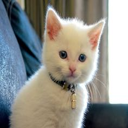

In [6]:
# let's download an  image
url = "https://huggingface.co/datasets/hf-internal-testing/diffusers-images/resolve/main/sd2-upscale/low_res_cat.png"
response = requests.get(url)
low_res_img = Image.open(BytesIO(response.content)).convert("RGB")
low_res_img = low_res_img.resize((128, 128))
prompt = "a white cat"

low_res_img

In [7]:
upscaled_image = pipeline(prompt=prompt, image=low_res_img).images[0]
upscaled_image.save("upsampled_cat.png")

  0%|          | 0/75 [00:00<?, ?it/s]

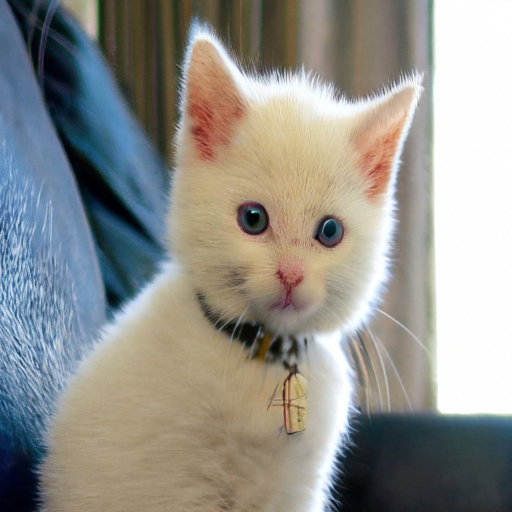

In [8]:
upscaled_image

In [9]:
superupscaled_image = pipeline(prompt=prompt, image=upscaled_image).images[0]
superupscaled_image.save("upsampled_cat.png")

  0%|          | 0/75 [00:00<?, ?it/s]

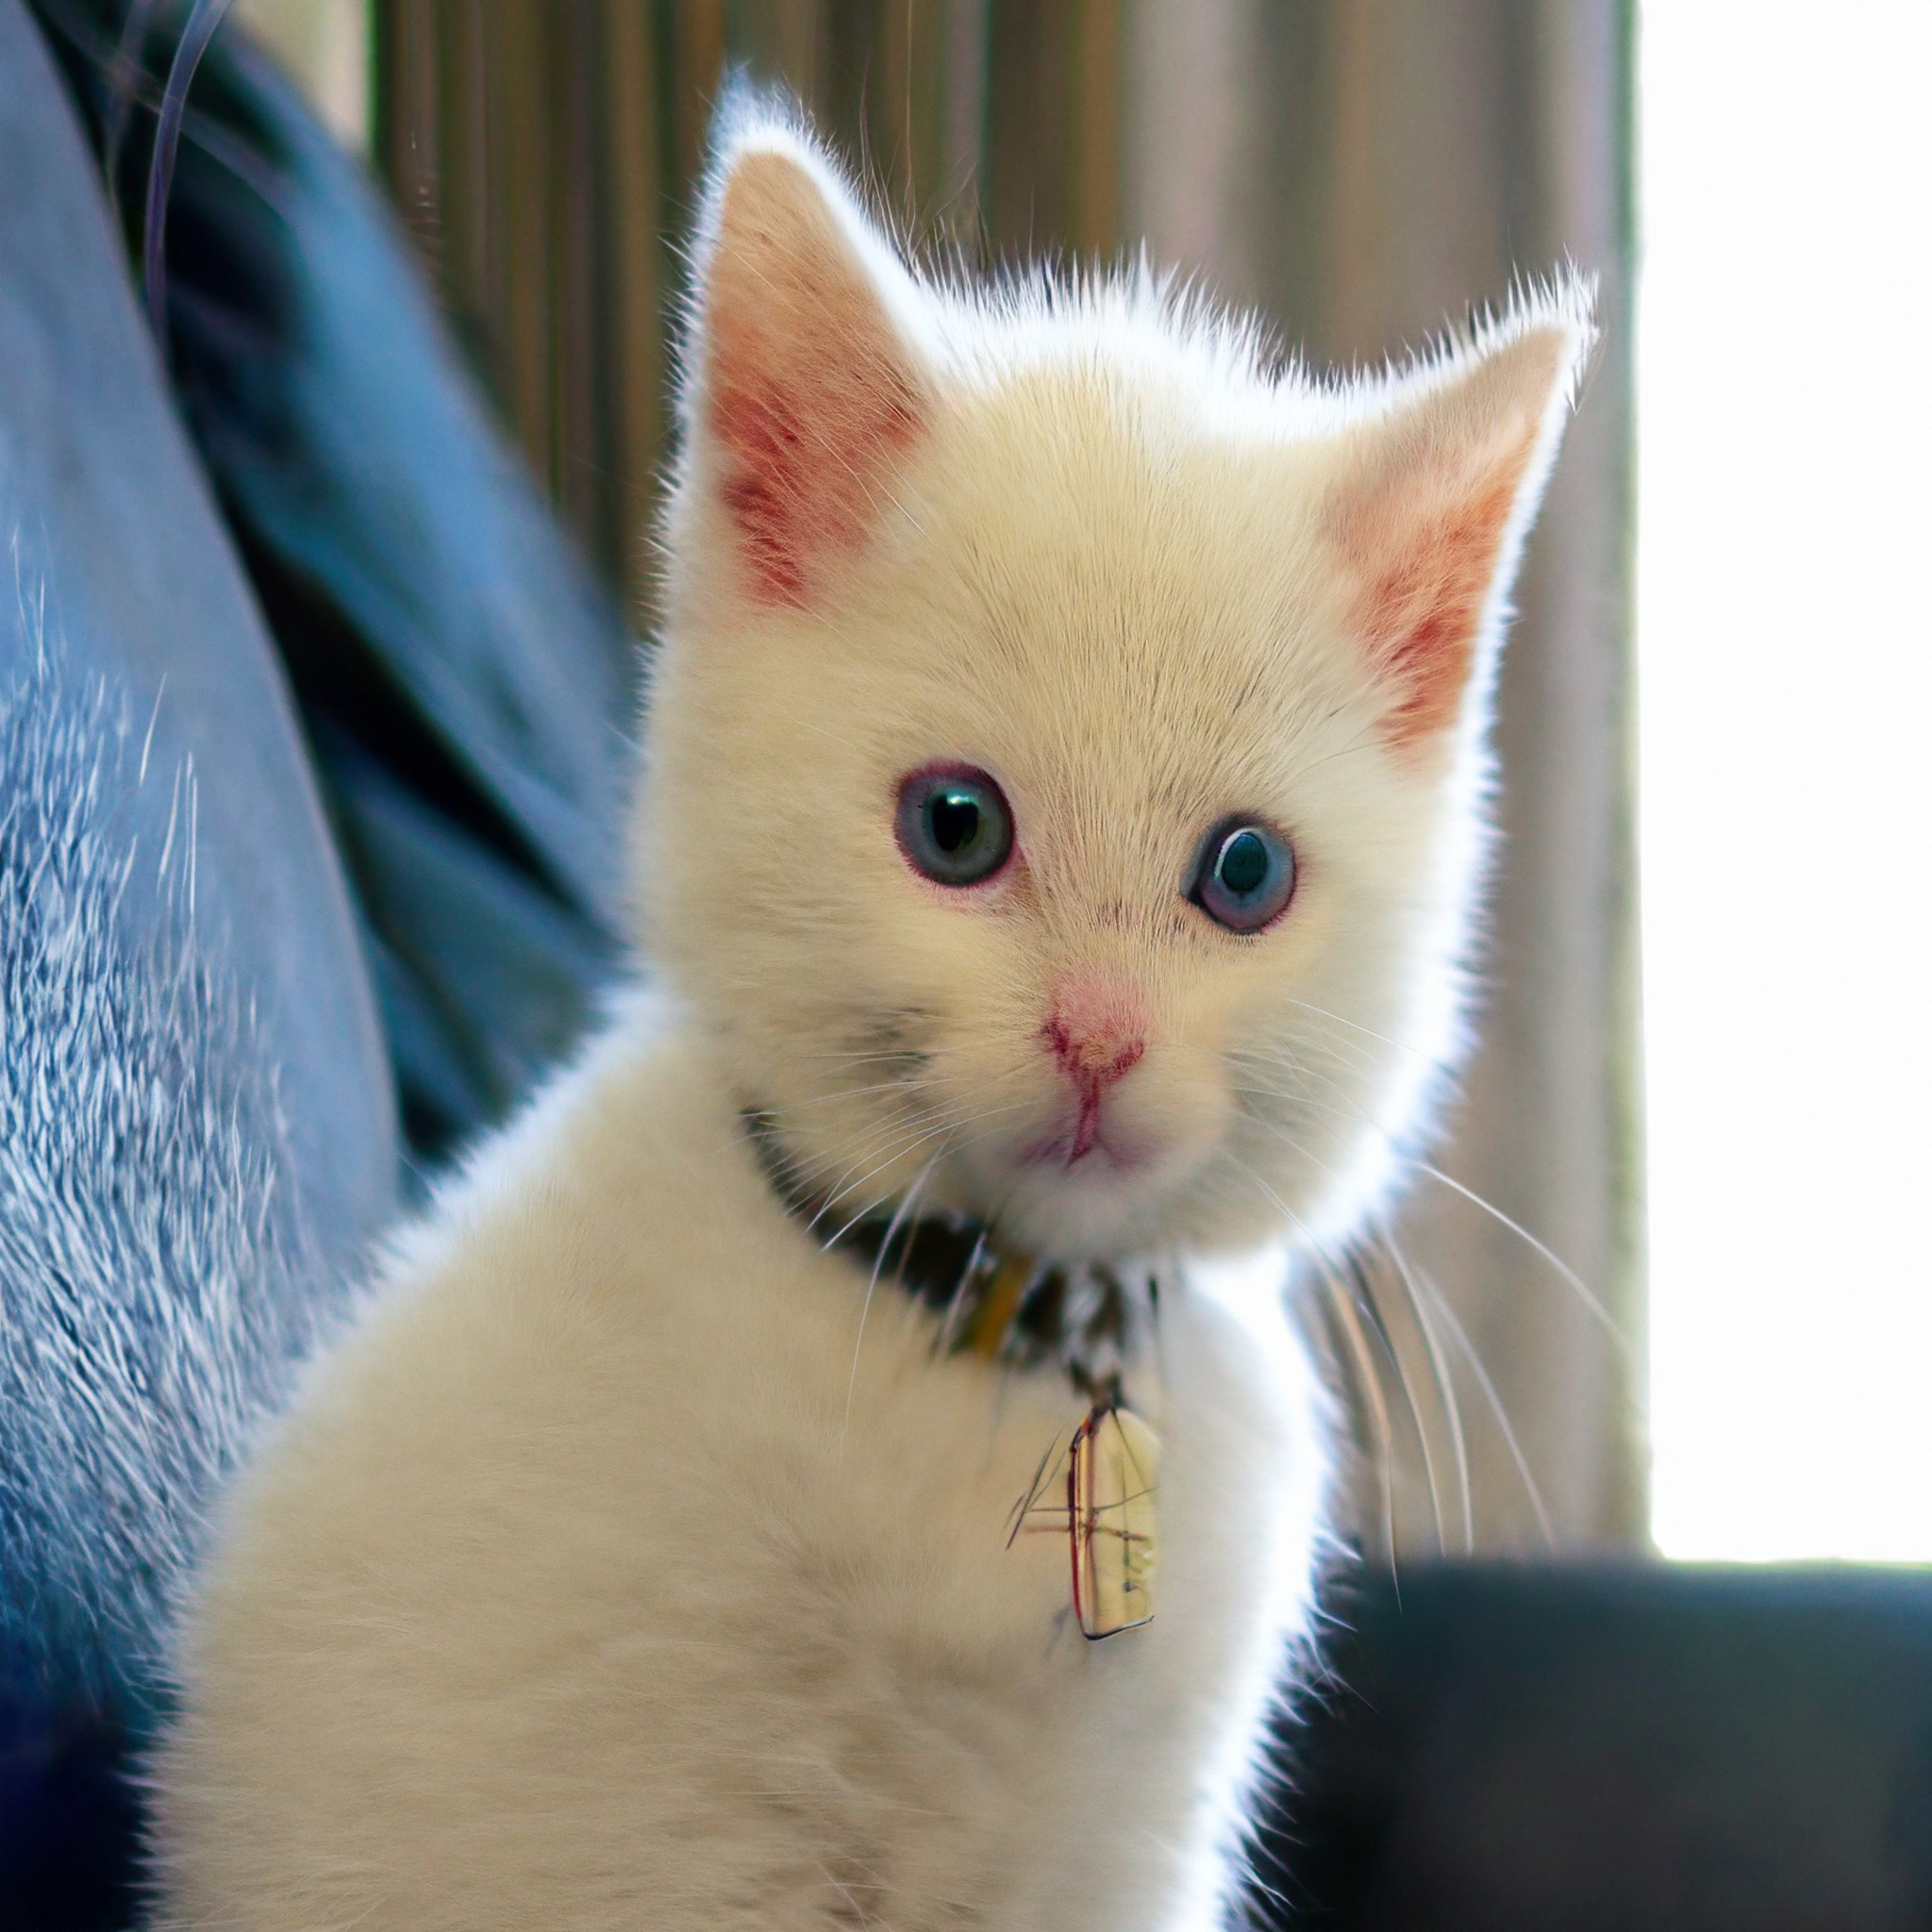

In [10]:
superupscaled_image